# SMC on Challenging 2D Densities

We apply Sequential Monte Carlo (geometric tempering) on the same three targets as the MCMC notebook:
1. **Neal's funnel** — varying curvature, strong correlation
2. **Gaussian mixture** — 5 well-separated modes, discrete multimodality
3. **Rosenbrock (banana)** — thin curved ridge, highly correlated

For each target we introduce a broad prior (standard Gaussian) and define the
log-likelihood as `log_target − log_prior`.  SMC then tempers from the prior
(t=0) to the full posterior (t=1).

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_platform_name", "cpu")

from probjax.inference.mcmc import hmc
from probjax.inference.smc import smc
from probjax.inference.smc.path import GeometricPath
from probjax.inference.smc_runner import SMC

## Target densities (log-unnormalized)

In [2]:
# --- Neal's funnel ---
def funnel_logdensity(z):
    x, v = z[0], z[1]
    return jax.scipy.stats.norm.logpdf(v, 0.0, 3.0) + \
           jax.scipy.stats.norm.logpdf(x, 0.0, jnp.exp(v / 2.0))


# --- Gaussian mixture ---
mixture_means = jnp.array([
    [10.0, 0.0], [0.0, 10.0], [-10.0, 0.0], [0.0, -10.0], [0.0, 0.0],
])
mixture_std = 0.7

def mixture_logdensity(z):
    logps = jax.vmap(
        lambda mu: jax.scipy.stats.norm.logpdf(z, mu, mixture_std).sum()
    )(mixture_means)
    return jax.scipy.special.logsumexp(logps) - jnp.log(len(mixture_means))


# --- Rosenbrock (banana) ---
def rosenbrock_logdensity(z):
    x, y = z[0], z[1]
    return -(1.0 - x) ** 2 - 10.0 * (y - x ** 2) ** 2

## Prior / likelihood split

We use a broad standard-normal prior and define the likelihood as
`log_target − log_prior` so that
`log_prior(z) + log_likelihood(z) = log_target(z)`.

In [3]:
prior_std = 5.0  # broad enough to cover all targets

def broad_logprior(z):
    return jax.scipy.stats.norm.logpdf(z, 0.0, prior_std).sum()


def funnel_loglikelihood(z):
    return funnel_logdensity(z) - broad_logprior(z)

def mixture_loglikelihood(z):
    return mixture_logdensity(z) - broad_logprior(z)

def rosenbrock_loglikelihood(z):
    return rosenbrock_logdensity(z) - broad_logprior(z)

## Reference samples

Direct samples (or rejection samples) for visual comparison.

In [4]:
key = jax.random.PRNGKey(42)

# Funnel
v_ref = jax.random.normal(key, (100_000,)) * 3.0
key, subkey = jax.random.split(key)
x_ref = jax.random.normal(subkey, (100_000,)) * jnp.exp(v_ref / 2.0)

# Mixture
key, subkey = jax.random.split(key)
comp = jax.random.choice(subkey, len(mixture_means), shape=(100_000,))
key, subkey = jax.random.split(key)
y_ref = mixture_means[comp] + jax.random.normal(subkey, (100_000, 2)) * mixture_std

# Rosenbrock (rejection sampling)
key, subkey = jax.random.split(key)
proposal_mean = jnp.array([1.0, 1.0])
proposal_std = jnp.array([1.0, 5.0])
candidates = jax.random.normal(subkey, (1_000_000, 2)) * proposal_std + proposal_mean
key, subkey = jax.random.split(key)
log_u = jax.random.uniform(subkey, (1_000_000,)) * 20.0 - 20.0
log_p = jax.vmap(rosenbrock_logdensity)(candidates)
log_g = jax.vmap(lambda z: jax.scipy.stats.norm.logpdf(z[0], 1.0, 1.0)
                          + jax.scipy.stats.norm.logpdf(z[1], 1.0, 5.0))(candidates)
mask = log_u < log_p - log_g
b_ref = candidates[mask][:100_000]

W0418 11:51:09.597831 5919345 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


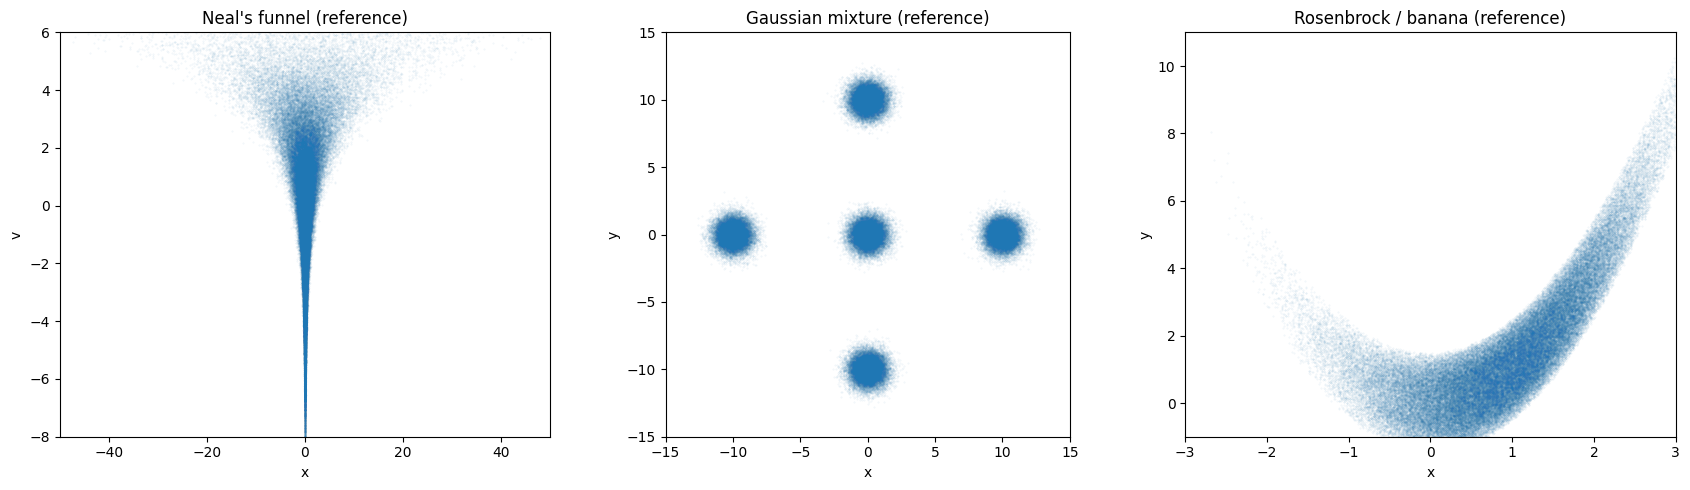

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(x_ref, v_ref, s=0.1, alpha=0.1, rasterized=True)
axes[0].set_xlim(-50, 50); axes[0].set_ylim(-8, 6)
axes[0].set_xlabel("x"); axes[0].set_ylabel("v")
axes[0].set_title("Neal's funnel (reference)")

axes[1].scatter(y_ref[:, 0], y_ref[:, 1], s=0.1, alpha=0.1, rasterized=True)
axes[1].set_xlim(-15, 15); axes[1].set_ylim(-15, 15)
axes[1].set_aspect("equal")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("Gaussian mixture (reference)")

axes[2].scatter(b_ref[:, 0], b_ref[:, 1], s=0.1, alpha=0.1, rasterized=True)
axes[2].set_xlim(-3, 3); axes[2].set_ylim(-1, 11)
axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
axes[2].set_title("Rosenbrock / banana (reference)")

plt.tight_layout()
plt.show()

## Helper

In [6]:
def run_smc(logprior_fn, loglikelihood_fn, num_particles, key,
            num_temps=100, num_mcmc_steps=4, num_integration_steps=10,
            step_size=0.1, tune=True):
    """Build an SMC kernel, initialise particles from the prior, and run."""
    key, subkey = jax.random.split(key)
    particles = jax.random.normal(subkey, (num_particles, 2)) * prior_std

    tempering_params = jnp.linspace(0.0, 1.0, num_temps)

    kernel = smc(
        path=GeometricPath(),
        logprior_fn=logprior_fn,
        loglikelihood_fn=loglikelihood_fn,
        mcmc_kernel=hmc,
        num_mcmc_steps=num_mcmc_steps,
        num_integration_steps=num_integration_steps,
    )

    state = kernel.init(particles, path=GeometricPath())
    params = kernel.init_params(
        particles,
        path=GeometricPath(),
        logprior_fn=logprior_fn,
        loglikelihood_fn=loglikelihood_fn,
        mcmc_kernel=hmc,
        num_integration_steps=num_integration_steps,
        step_size=step_size,
    )

    runner = SMC(kernel)
    final_state, final_params = runner.run(
        key, state, tempering_params, params, tune_params=tune
    )
    return final_state.particles, final_state.weights


def plot_triplet(name, s_funnel, s_mixture, s_rosenbrock,
                 w_funnel=None, w_mixture=None, w_rosenbrock=None):
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    axes[0].scatter(s_funnel[:, 0], s_funnel[:, 1], s=0.5, alpha=0.4, rasterized=True)
    axes[0].set_xlim(-50, 50); axes[0].set_ylim(-8, 6)
    axes[0].set_xlabel("x"); axes[0].set_ylabel("v")
    axes[0].set_title(f"{name} — funnel")

    axes[1].scatter(s_mixture[:, 0], s_mixture[:, 1], s=0.5, alpha=0.4, rasterized=True)
    axes[1].set_xlim(-15, 15); axes[1].set_ylim(-15, 15)
    axes[1].set_aspect("equal")
    axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
    axes[1].set_title(f"{name} — mixture")

    axes[2].scatter(s_rosenbrock[:, 0], s_rosenbrock[:, 1], s=0.5, alpha=0.4, rasterized=True)
    axes[2].set_xlim(-3, 3); axes[2].set_ylim(-1, 11)
    axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
    axes[2].set_title(f"{name} — Rosenbrock")

    plt.tight_layout()
    plt.show()

In [7]:
num_particles = 20_000
key = jax.random.PRNGKey(0)

## SMC + HMC (geometric tempering)

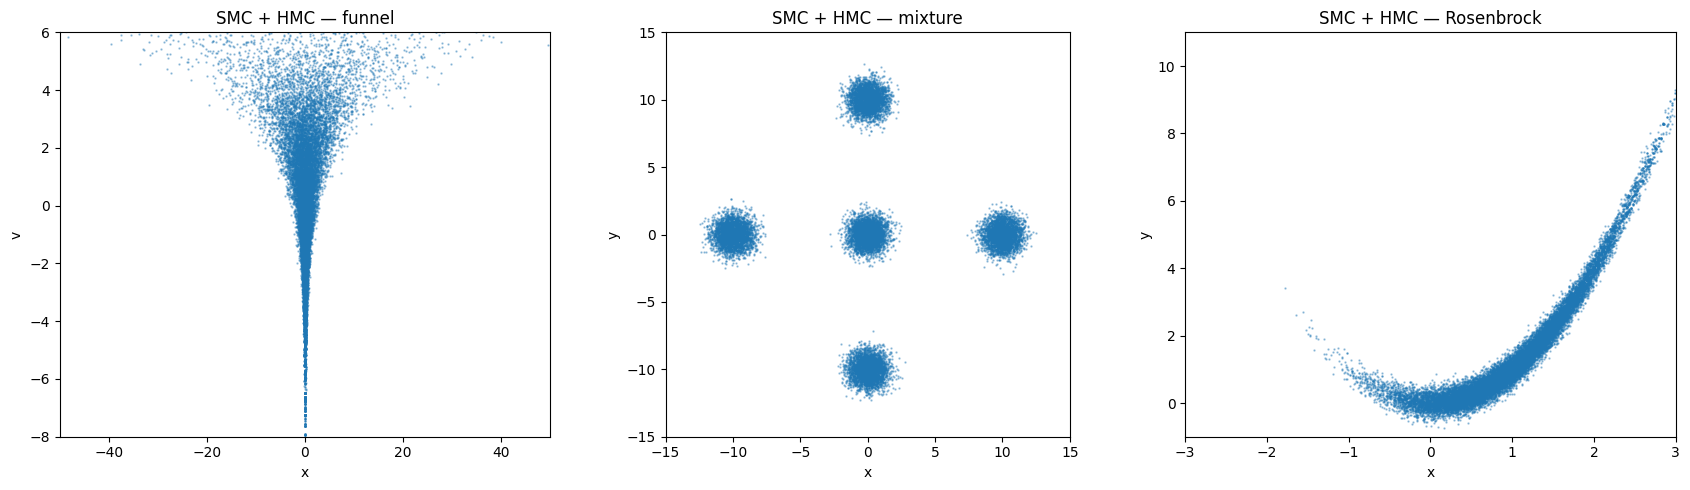

In [8]:
key, k1, k2, k3 = jax.random.split(key, 4)

p_f, w_f = run_smc(broad_logprior, funnel_loglikelihood, num_particles, k1,
                   num_mcmc_steps=8, num_integration_steps=20, step_size=0.05)
p_m, w_m = run_smc(broad_logprior, mixture_loglikelihood, num_particles, k2,
                   num_mcmc_steps=8, num_integration_steps=20, step_size=0.05)
p_b, w_b = run_smc(broad_logprior, rosenbrock_loglikelihood, num_particles, k3,
                   num_mcmc_steps=8, num_integration_steps=10, step_size=0.05)

plot_triplet("SMC + HMC", p_f, p_m, p_b)

## Effect of more tempering steps

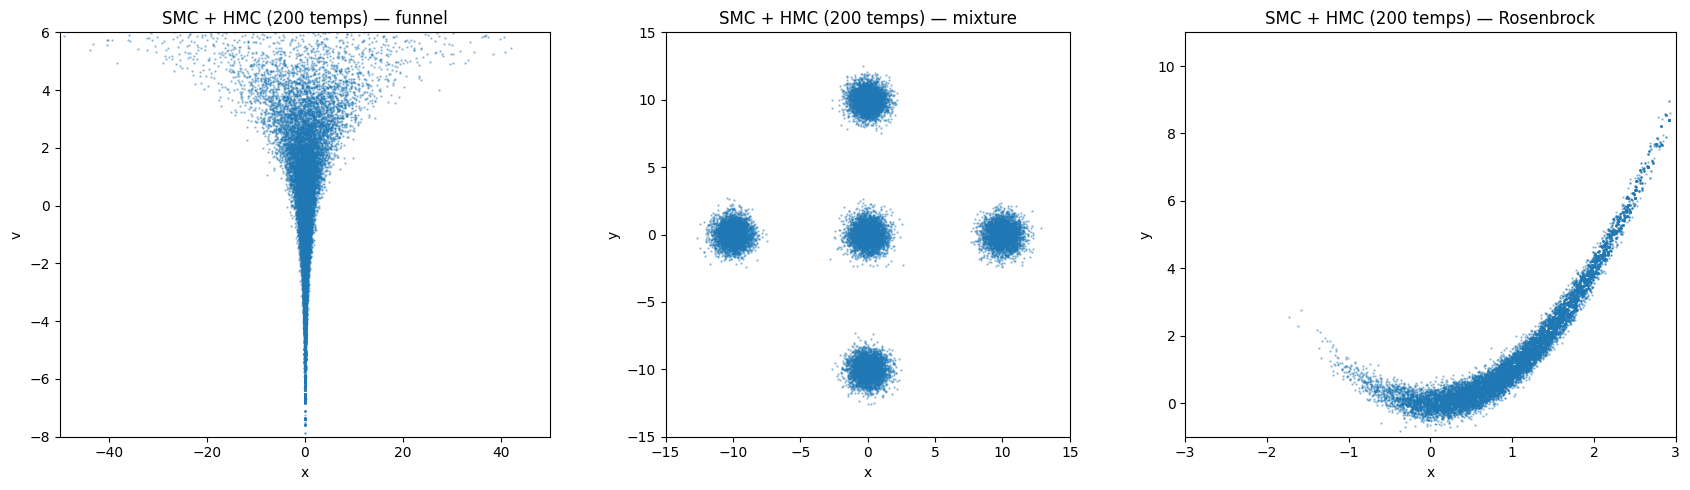

In [9]:
key, k1, k2, k3 = jax.random.split(key, 4)

p_f, w_f = run_smc(broad_logprior, funnel_loglikelihood, num_particles, k1,
                   num_temps=200, num_mcmc_steps=8, num_integration_steps=20, step_size=0.05)
p_m, w_m = run_smc(broad_logprior, mixture_loglikelihood, num_particles, k2,
                   num_temps=200, num_mcmc_steps=8, num_integration_steps=20, step_size=0.05)
p_b, w_b = run_smc(broad_logprior, rosenbrock_loglikelihood, num_particles, k3,
                   num_temps=200, num_mcmc_steps=8, num_integration_steps=10, step_size=0.05)

plot_triplet("SMC + HMC (200 temps)", p_f, p_m, p_b)

## Effect of more MCMC steps per tempering level

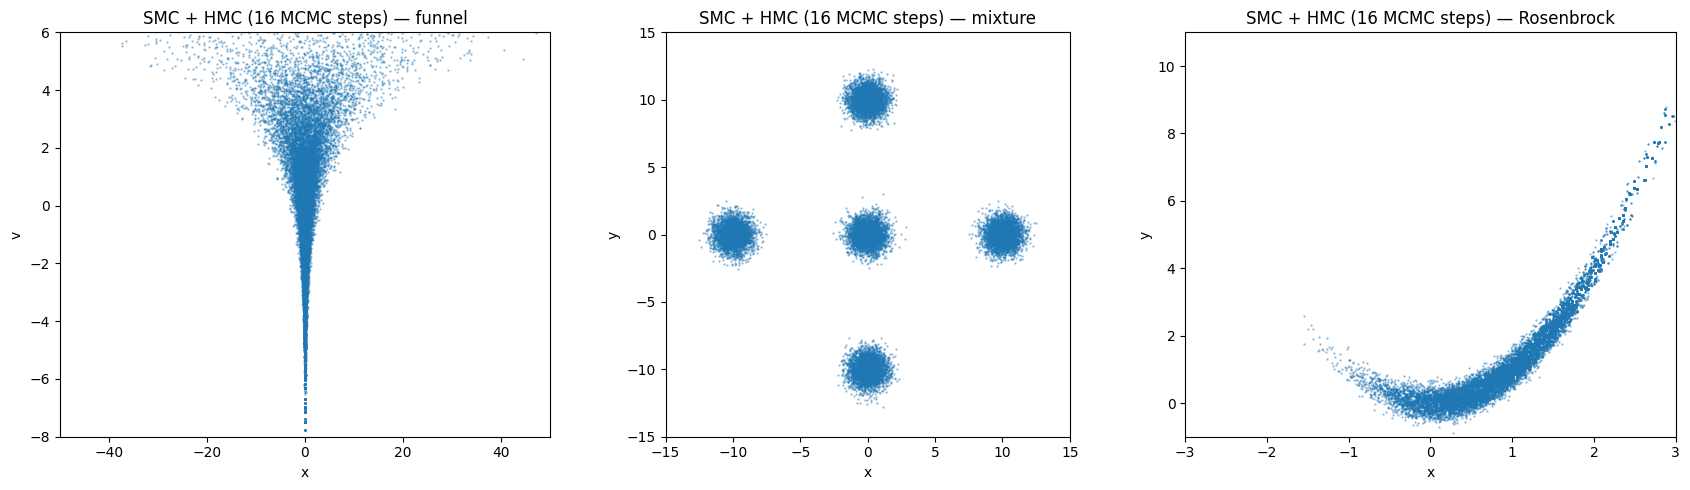

In [10]:
key, k1, k2, k3 = jax.random.split(key, 4)

p_f, w_f = run_smc(broad_logprior, funnel_loglikelihood, num_particles, k1,
                   num_mcmc_steps=16, num_integration_steps=20, step_size=0.1)
p_m, w_m = run_smc(broad_logprior, mixture_loglikelihood, num_particles, k2,
                   num_mcmc_steps=16, num_integration_steps=20, step_size=0.1)
p_b, w_b = run_smc(broad_logprior, rosenbrock_loglikelihood, num_particles, k3,
                   num_mcmc_steps=16, num_integration_steps=10, step_size=0.05)

plot_triplet("SMC + HMC (16 MCMC steps)", p_f, p_m, p_b)

## Sampling history

Use `runner.sample` to inspect how particles evolve across the tempering schedule.

In [11]:
key, subkey = jax.random.split(key)
particles = jax.random.normal(subkey, (num_particles, 2)) * prior_std

tempering_params = jnp.linspace(0.0, 1.0, 50)

kernel = smc(
    path=GeometricPath(),
    logprior_fn=broad_logprior,
    loglikelihood_fn=mixture_loglikelihood,
    mcmc_kernel=hmc,
    num_mcmc_steps=4,
    num_integration_steps=20,
)

state = kernel.init(particles, path=GeometricPath())
params = kernel.init_params(
    particles,
    path=GeometricPath(),
    logprior_fn=broad_logprior,
    loglikelihood_fn=mixture_loglikelihood,
    mcmc_kernel=hmc,
    num_integration_steps=20,
    step_size=0.1,
)

runner = SMC(kernel)
particles_hist, weights_hist, final_state, final_params = runner.sample(
    key, state, tempering_params, params, tune_params=True
)

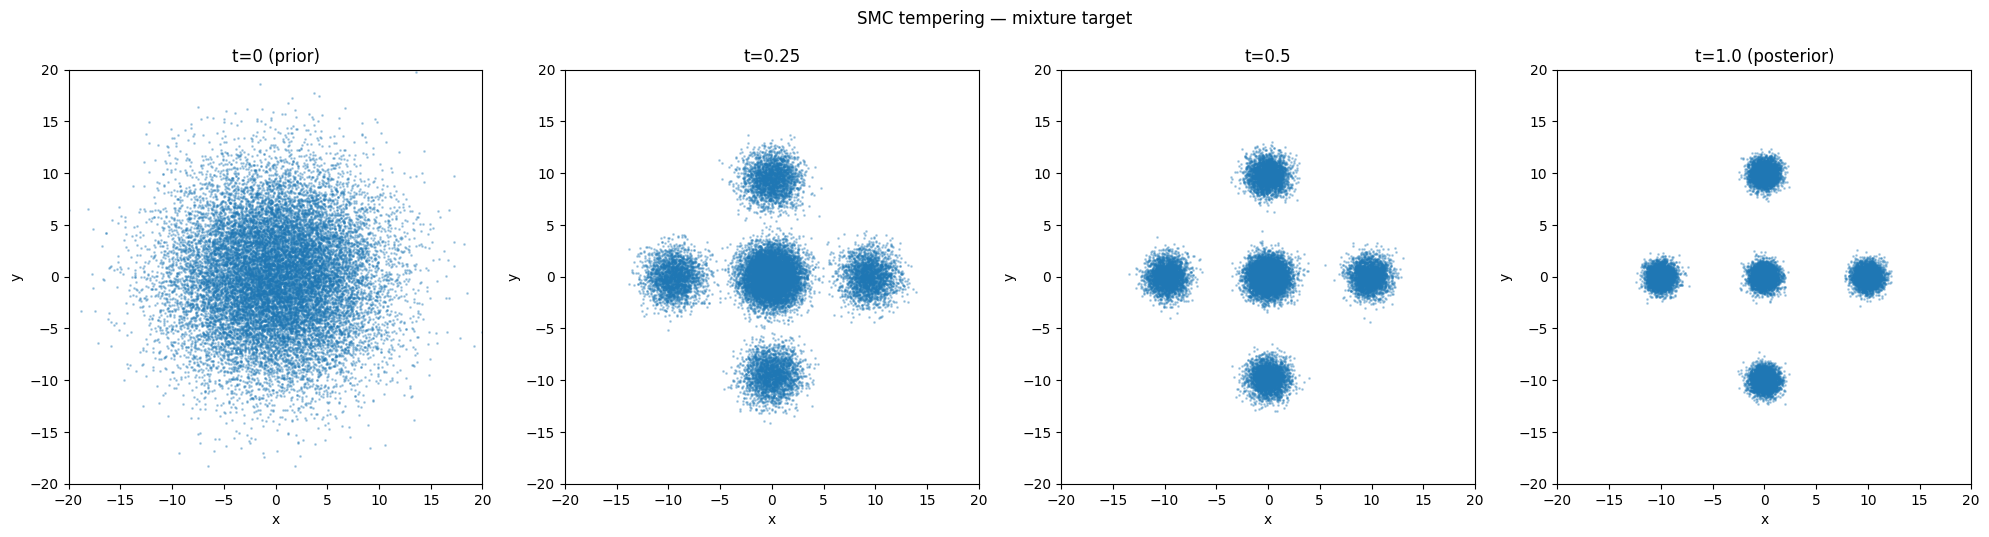

In [12]:
snapshots = [0, len(tempering_params) // 4, len(tempering_params) // 2, -1]
labels = ["t=0 (prior)", "t=0.25", "t=0.5", "t=1.0 (posterior)"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, idx, label in zip(axes, snapshots, labels):
    pts = particles_hist[idx]
    ax.scatter(pts[:, 0], pts[:, 1], s=1, alpha=0.3, rasterized=True)
    ax.set_xlim(-20, 20); ax.set_ylim(-20, 20)
    ax.set_aspect("equal")
    ax.set_title(label)
    ax.set_xlabel("x"); ax.set_ylabel("y")

fig.suptitle("SMC tempering — mixture target", y=1.02)
plt.tight_layout()
plt.show()

## Observations

**Prior choice matters.** SMC starts from the prior at t=0, so particles are
initially scattered across a wide Gaussian. The tempering bridge must transport
them to the target. A well-chosen prior (covering all modes, roughly matching
the target's scale) makes the path easier.

**Funnel:** SMC with HMC inner kernels handles the varying curvature well,
especially with enough integration steps. The tempering helps — at low t the
posterior is nearly the prior, so MCMC moves are large and free.

**Mixture:** SMC excels here compared to single-chain MCMC. Resampling naturally
clones particles that find modes and kills those stuck in low-density regions.
Even 50 tempering steps can discover all 5 modes.

**Rosenbrock:** The thin ridge is hard for any method. More tempering steps and
careful step-size tuning are important. SMC's resampling helps concentrate
particles on the ridge, but the HMC inner kernel still needs enough leapfrog
steps to follow the curvature.